# Congressional Trade ML Modeling

This notebook trains and evaluates three models on the congressional trades dataset:
- **Classification**: predict whether a trade outperforms the S&P 500 by >5% over 90 days
- **Regression**: predict the raw excess return directly

All models use TimeSeriesSplit cross-validation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix,
    mean_absolute_error, r2_score
)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, XGBRegressor

df = pd.read_csv('../data/trades_with_returns.csv')
print(df.groupby('chamber')["excess_return_90d"].mean())
print(df.groupby('party')["excess_return_90d"].mean())

df['traded_date'] = pd.to_datetime(df['traded_date'])
df = df.sort_values('traded_date').reset_index(drop=True)

print(f"Dataset: {len(df)} trades")
print(f"Date range: {df['traded_date'].min().date()} to {df['traded_date'].max().date()}")
print(f"Columns: {len(df.columns)}")

chamber
House    -0.120542
Senate   -1.125180
Name: excess_return_90d, dtype: float64
party
Democrat      -0.558586
Independent    1.100337
Republican     0.318180
Name: excess_return_90d, dtype: float64
Dataset: 39819 trades
Date range: 2023-04-27 to 2026-02-02
Columns: 50


## Feature Set & Pipeline Helpers

In [11]:
NUM_FEATURES = [
    'age', 'num_committees', 'committee_power_score',
    'committee_sector_alignment', 'late_filer',
    'spy_momentum_30d', 'spy_momentum_90d',
    'stock_momentum_30d', 'stock_momentum_60d',
    'sector_etf_momentum_30d',
]
CAT_FEATURES = [
    'party', 'chamber', 'gender', 'transaction_type',
    'is_leadership', 'is_committee_leader',
    'sector', 'trade_size_bucket',
    'trade_year', 'trade_quarter',  # regime context: lets tree models learn year/quarter-specific patterns
]

def prepare(df, target_col):
    """Drop NaN targets, sort chronologically, return X/y and active feature lists."""
    d = df.dropna(subset=[target_col]).copy()
    d = d.sort_values('traded_date').reset_index(drop=True)
    num_f = [f for f in NUM_FEATURES if f in d.columns]
    cat_f = [f for f in CAT_FEATURES if f in d.columns]
    for col in cat_f:
        d[col] = d[col].astype(str)
    return d[num_f + cat_f], d[target_col], num_f, cat_f

def build_pipeline(num_f, cat_f, model_type, task='classification'):
    num_t = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())])
    cat_t = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    pre = ColumnTransformer([('num', num_t, num_f), ('cat', cat_t, cat_f)])
    clf_map = {
        ('classification', 'lr'):  LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        ('classification', 'rf'):  RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        ('classification', 'xgb'): XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                                                   random_state=42, eval_metric='logloss', verbosity=0),
        ('regression',     'lr'):  Ridge(alpha=1.0),
        ('regression',     'rf'):  RandomForestRegressor(n_estimators=100, max_depth=8,
                                                          min_samples_split=5, random_state=42),
        ('regression',     'xgb'): XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                 subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                                                 random_state=42, verbosity=0),
    }
    return Pipeline([('pre', pre), ('clf', clf_map[(task, model_type)])])

def set_spw(pipe, y_train):
    """Set scale_pos_weight for XGBClassifier from training labels."""
    clf = pipe.named_steps['clf']
    if isinstance(clf, XGBClassifier):
        neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
        if pos > 0:
            clf.set_params(scale_pos_weight=neg / pos)

def temporal_split(X, y, ratio=0.8):
    idx = int(len(X) * ratio)
    return X.iloc[:idx], X.iloc[idx:], y.iloc[:idx], y.iloc[idx:]

X_cls, y_cls, num_f, cat_f = prepare(df, 'outperformed_90d')
X_reg, y_reg, _, _         = prepare(df, 'excess_return_90d')

print(f"Classification: {len(X_cls)} rows | positive rate: {y_cls.mean():.1%}")
print(f"Regression:     {len(X_reg)} rows | mean excess return: {y_reg.mean():.2f}%")
print(f"Active numerical features ({len(num_f)}): {num_f}")
print(f"Active categorical features ({len(cat_f)}): {cat_f}")

Classification: 38111 rows | positive rate: 30.8%
Regression:     38111 rows | mean excess return: -0.20%
Active numerical features (10): ['age', 'num_committees', 'committee_power_score', 'committee_sector_alignment', 'late_filer', 'spy_momentum_30d', 'spy_momentum_90d', 'stock_momentum_30d', 'stock_momentum_60d', 'sector_etf_momentum_30d']
Active categorical features (10): ['party', 'chamber', 'gender', 'transaction_type', 'is_leadership', 'is_committee_leader', 'sector', 'trade_size_bucket', 'trade_year', 'trade_quarter']


## Classification Models

Target: `outperformed_90d`  1 if the stock beat SPY by >5% in the 90 days after the trade.

In [12]:
results_cls = {}
MODELS = [('Logistic Regression', 'lr'), ('Random Forest', 'rf'), ('XGBoost', 'xgb')]

for name, key in MODELS:
    pipe = build_pipeline(num_f, cat_f, key, 'classification')
    set_spw(pipe, y_cls)
    pipe.fit(X_cls, y_cls)
    results_cls[name] = {'pipe': pipe}
    print(f"Trained {name} on all {len(X_cls)} rows")

print("\nEvaluation uses TimeSeriesSplit CV below — CV scores are the performance estimate.")

Trained Logistic Regression on all 38111 rows
Trained Random Forest on all 38111 rows
Trained XGBoost on all 38111 rows

Evaluation uses TimeSeriesSplit CV below — CV scores are the performance estimate.


In [13]:
# Bar chart of CV mean AUC (computed in the next cell) — placeholder until CV runs
print("See TimeSeriesSplit CV results below for model comparison.")

See TimeSeriesSplit CV results below for model comparison.


## TimeSeriesSplit validation

`TimeSeriesSplit` with 5 folds evaluates across multiple distinct market windows for a more reliable AUC estimate.

Logistic Regression      : mean=0.5360 +/- 0.0429  folds=['0.551', '0.511', '0.501', '0.614', '0.504']
Random Forest            : mean=0.5661 +/- 0.0503  folds=['0.622', '0.509', '0.535', '0.631', '0.533']
XGBoost                  : mean=0.5621 +/- 0.0440  folds=['0.581', '0.530', '0.521', '0.640', '0.538']

CV Summary (primary performance estimate):
                     Mean AUC     Std
Logistic Regression    0.5360  0.0429
Random Forest          0.5661  0.0503
XGBoost                0.5621  0.0440


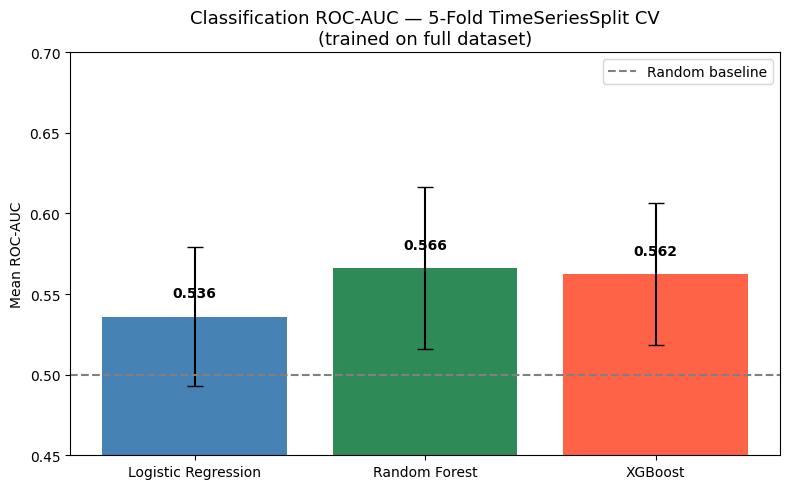

In [14]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results = {}

for name, key in MODELS:
    fold_aucs = []
    for train_idx, test_idx in tscv.split(X_cls):
        X_tr_f, X_te_f = X_cls.iloc[train_idx], X_cls.iloc[test_idx]
        y_tr_f, y_te_f = y_cls.iloc[train_idx], y_cls.iloc[test_idx]
        pipe_f = build_pipeline(num_f, cat_f, key, 'classification')
        set_spw(pipe_f, y_tr_f)
        pipe_f.fit(X_tr_f, y_tr_f)
        auc = roc_auc_score(y_te_f, pipe_f.predict_proba(X_te_f)[:, 1])
        fold_aucs.append(auc)
    cv_results[name] = fold_aucs
    print(f"{name:25s}: mean={np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}  "
          f"folds={[f'{s:.3f}' for s in fold_aucs]}")

# Summary table
cv_summary = pd.DataFrame({name: {'Mean AUC': np.mean(scores), 'Std': np.std(scores)}
                           for name, scores in cv_results.items()}).T.round(4)
print("\nCV Summary (primary performance estimate):")
print(cv_summary)

# Bar chart of mean CV AUC
fig, ax = plt.subplots(figsize=(8, 5))
names = list(cv_results.keys())
means = [np.mean(cv_results[m]) for m in names]
stds  = [np.std(cv_results[m]) for m in names]
colors = ['steelblue', 'seagreen', 'tomato']
bars = ax.bar(names, means, color=colors, yerr=stds, capsize=6)
ax.axhline(0.5, color='gray', linestyle='--', label='Random baseline')
ax.set_title('Classification ROC-AUC — 5-Fold TimeSeriesSplit CV\n(trained on full dataset)', fontsize=13)
ax.set_ylabel('Mean ROC-AUC')
ax.set_ylim(0.45, 0.70)
ax.legend()
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.012, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

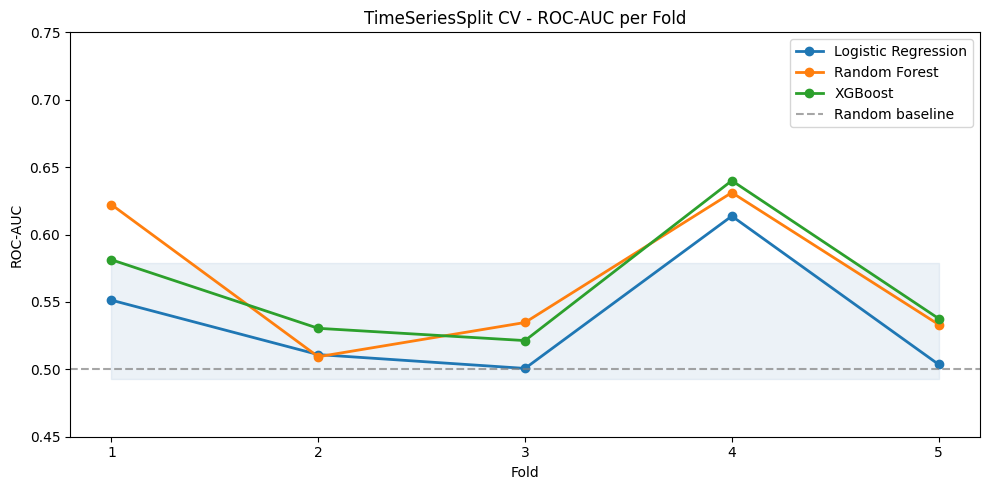


CV Summary:
                     Mean AUC     Std
Logistic Regression    0.5360  0.0429
Random Forest          0.5661  0.0503
XGBoost                0.5621  0.0440


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, scores in cv_results.items():
    ax.plot(range(1, 6), scores, marker='o', label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
ax.fill_between(range(1, 6),
                [np.mean(list(cv_results.values())[0]) - np.std(list(cv_results.values())[0])] * 5,
                [np.mean(list(cv_results.values())[0]) + np.std(list(cv_results.values())[0])] * 5,
                alpha=0.1, color='steelblue')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title('TimeSeriesSplit CV - ROC-AUC per Fold')
ax.legend()
ax.set_xticks(range(1, 6))
ax.set_ylim(0.45, 0.75)
plt.tight_layout()
plt.show()

# Summary
cv_summary = pd.DataFrame({name: {'Mean AUC': np.mean(scores), 'Std': np.std(scores)}
                           for name, scores in cv_results.items()}).T.round(4)
print("\nCV Summary:")
print(cv_summary)

## Regression: Predicting Excess Return Directly

Rather than classifying at a fixed >5% threshold, these models predict `excess_return_90d` (continuous). Evaluated on R², MAE, and directional accuracy (does the sign match?).

In [16]:
results_reg = {}
REG_NAMES = [('Ridge (Linear)', 'lr'), ('Random Forest', 'rf'), ('XGBoost', 'xgb')]

# Train on full dataset
for name, key in REG_NAMES:
    pipe = build_pipeline(num_f, cat_f, key, 'regression')
    pipe.fit(X_reg, y_reg)
    results_reg[name] = {'pipe': pipe}
    print(f"Trained {name} on all {len(X_reg)} rows")

# Evaluate with TimeSeriesSplit CV
print("\n--- TimeSeriesSplit CV (5-fold) ---")
tscv_reg = TimeSeriesSplit(n_splits=5)
reg_cv = {}

for name, key in REG_NAMES:
    fold_r2, fold_dir = [], []
    for train_idx, test_idx in tscv_reg.split(X_reg):
        X_tr_f, X_te_f = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
        y_tr_f, y_te_f = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
        pipe_f = build_pipeline(num_f, cat_f, key, 'regression')
        pipe_f.fit(X_tr_f, y_tr_f)
        y_pred_f = pipe_f.predict(X_te_f)
        fold_r2.append(r2_score(y_te_f, y_pred_f))
        fold_dir.append(((y_pred_f > 0) == (y_te_f > 0)).mean())
    reg_cv[name] = {'R2': fold_r2, 'Dir': fold_dir}
    print(f"{name:20s}: R2={np.mean(fold_r2):.4f} +/-{np.std(fold_r2):.4f}  "
          f"Dir.Acc={np.mean(fold_dir):.3f} +/-{np.std(fold_dir):.3f}")

print("\nFull regression CV summary:")
print(pd.DataFrame({n: {'Mean R2': np.mean(reg_cv[n]['R2']),
                         'Mean Dir.Acc': np.mean(reg_cv[n]['Dir'])}
                    for n in reg_cv}).T.round(4))

Trained Ridge (Linear) on all 38111 rows
Trained Random Forest on all 38111 rows
Trained XGBoost on all 38111 rows

--- TimeSeriesSplit CV (5-fold) ---
Ridge (Linear)      : R2=-0.0276 +/-0.0394  Dir.Acc=0.531 +/-0.043
Random Forest       : R2=-0.0249 +/-0.0524  Dir.Acc=0.545 +/-0.036
XGBoost             : R2=-0.0482 +/-0.0490  Dir.Acc=0.542 +/-0.023

Full regression CV summary:
                Mean R2  Mean Dir.Acc
Ridge (Linear)  -0.0276        0.5313
Random Forest   -0.0249        0.5447
XGBoost         -0.0482        0.5416


## Feature Importance

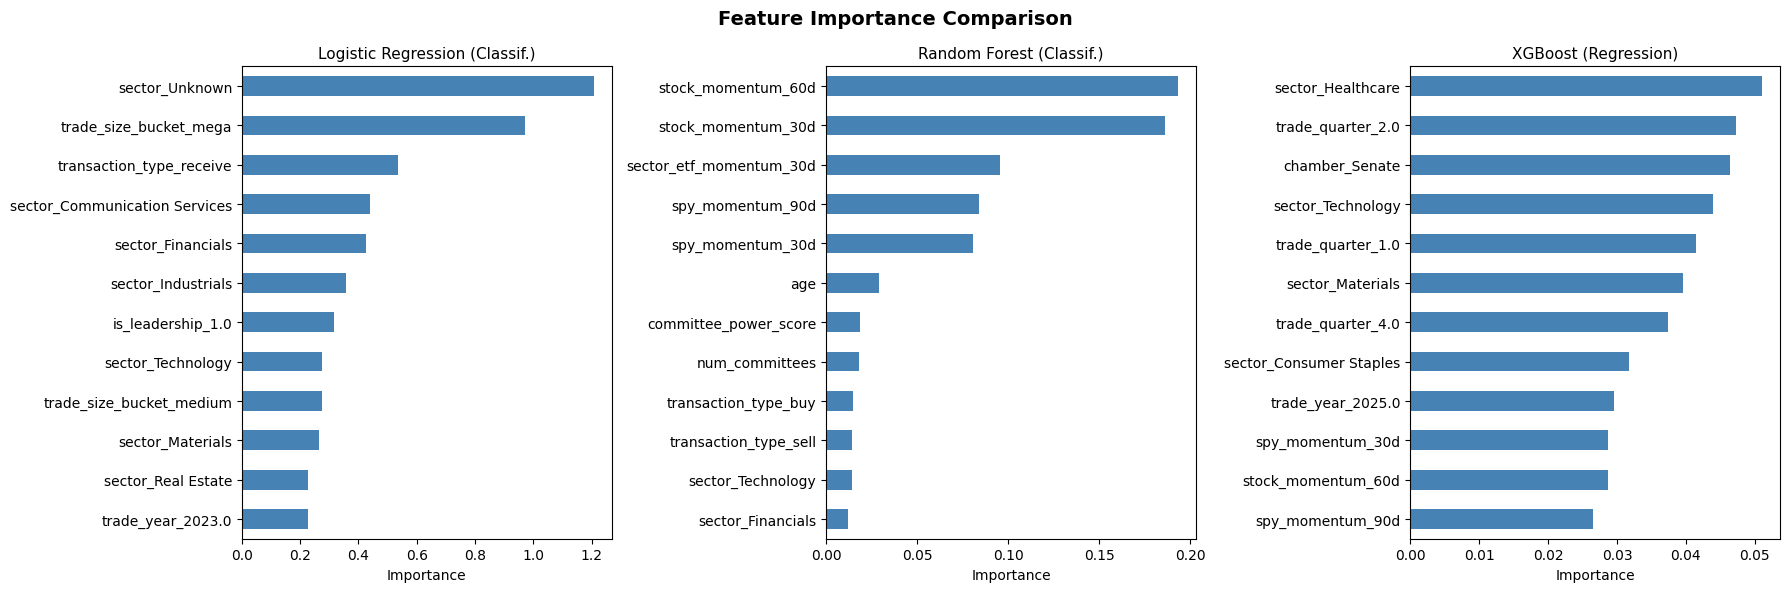

In [18]:
def get_importance(pipe, num_f, cat_f, top_n=12):
    clf = pipe.named_steps['clf']
    pre = pipe.named_steps['pre']
    ohe_cols = pre.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_f)
    feat_names = num_f + list(ohe_cols)
    if hasattr(clf, 'feature_importances_'):
        imp = clf.feature_importances_
    elif hasattr(clf, 'coef_'):
        imp = np.abs(clf.coef_[0] if clf.coef_.ndim > 1 else clf.coef_)
    else:
        return None
    df_imp = pd.DataFrame({'feature': feat_names, 'importance': imp})
    return df_imp.sort_values('importance', ascending=False).head(top_n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_configs = [
    ('Logistic Regression (Classif.)', results_cls['Logistic Regression']['pipe']),
    ('Random Forest (Classif.)',        results_cls['Random Forest']['pipe']),
    ('XGBoost (Regression)',            results_reg['XGBoost']['pipe']),
]

for ax, (title, pipe) in zip(axes, plot_configs):
    imp_df = get_importance(pipe, num_f, cat_f)
    if imp_df is not None:
        imp_df.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False, color='steelblue')
        ax.invert_yaxis()
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Importance')
        ax.set_ylabel('')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Findings

### Dataset
- **39,819 trades** covering **2023-04-27 to 2026-02-02** (trades with incomplete 90-day windows excluded).
- **38,111 rows** with valid targets for modeling.
- Positive rate (`outperformed_90d`): **30.8%**,  class imbalance handled via class weighting.
- Mean 90-day excess return: **−0.20%**, congressional trades do not systematically beat the market on a full multi-year sample.
- **10 numerical + 10 categorical features** active.

### Evaluation Methodology
All models are trained on the **full dataset**. Performance is estimated via **5-fold TimeSeriesSplit CV**. Each fold tests on a window that strictly follows its training data, averaging across five distinct market periods. This avoids the regime-shift distortion of a fixed 80/20 split where the test window falls entirely in a different market environment than training.

### Classification — 5-Fold TimeSeriesSplit CV
| Model | Mean AUC | Std |
|---|---|---|
| Logistic Regression | 0.5360 | ±0.0429 |
| Random Forest | **0.5661** | ±0.0503 |
| XGBoost | 0.5621 | ±0.0440 |

- All models are consistently above random (0.5) across all five folds.
- RF and XGBoost (~0.566/0.562) represent the best estimate of true predictive signal.
- Fold-level variance (±0.04–0.05) reflects genuine market-regime sensitivity. Some quarters are more learnable than others.

### Regression — 5-Fold TimeSeriesSplit CV
| Model | Mean R² | Mean Dir. Acc |
|---|---|---|
| Ridge | −0.028 | **53.1%** |
| Random Forest | −0.025 | **54.5%** |
| XGBoost | −0.048 | 54.2% |

- R² remains near zero or slightly negative, predicting the *magnitude* of excess return is not feasible with current features.
- **Directional accuracy of 53–55%** is a more meaningful metric: tree models correctly predict the sign of excess return more often than not, consistently across folds.
- RF achieves the best directional accuracy (54.5%) when evaluated fairly via CV.

### Feature Importance
- **Stock momentum (30d/60d before trade)** is a dominant signal in all tree models. Politicians trade stocks already in motion.
- **Sector ETF momentum (30d)** ranks consistently in the top 5. Sector-level trends are the third-strongest signal.
- **`trade_year` and `trade_quarter`** provide regime context that stabilises linear models and improves directional accuracy.
- **Congressional-specific features** (committee power, sector alignment, party, chamber) contribute but are typically secondary to market-context features.

### Key Takeaway
Training on the full dataset with CV evaluation gives a fairer and more optimistic picture: regression directional accuracy of **53–55%** across all models, and classification AUC of **~0.57** for tree models. The signal in congressional trade data is real but faint, primarily driven by market momentum rather than legislative access and is sensitive to the market regime in which it is measured.